**Iris Flower Species Classification Using K-Nearest Neighbour (KNN) Supervised Machine Learning Mode** or **Prediction of Iris Flower Species Using the K-Nearest Neighbour (KNN) Classification Algorithm**

In [11]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dataset URL
url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/iris.xls"

# Load Dataset
df = pd.read_excel(url)

# Display First Five Rows
df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**Meaning of Code Block 1**

This code block imports the required Python libraries for data handling, machine learning model development, and model evaluation. It then loads the Iris Flower dataset directly from the GitHub repository using its raw URL into a Pandas DataFrame. Finally, it displays the first five records of the dataset to verify that the data has been imported successfully and to understand its structure before developing the K-Nearest Neighbour (KNN) supervised machine learning model for classifying iris flower species.

In [12]:
# Select Input Features (X)
X = df.drop(columns=["Species"])

# Select Target Variable (Y)
y = df["Species"]

**Meaning of Code Block 2**

This code block separates the dataset into input features (X) and the target variable (Y). The input features (X) consist of four measurements of each iris flower: Sepal Length, Sepal Width, Petal Length, and Petal Width. The target variable (Y) is the Species column, which contains the three iris flower species: Iris-setosa, Iris-versicolor, and Iris-virginica. The K-Nearest Neighbour (KNN) algorithm uses these four measurements to learn the characteristics of each species and classify new iris flowers into their correct species.

In [13]:
# Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Meaning of Code Block 3**

This code block divides the Iris dataset into two parts: a training dataset and a testing dataset. The training dataset (80%) is used to train the K-Nearest Neighbour (KNN) machine learning model, while the testing dataset (20%) is used to evaluate the model's performance on previously unseen iris flower samples. This approach helps determine how well the model can classify new flowers. The random_state=42 parameter ensures that the dataset is split in the same way every time the program is executed, making the results consistent and reproducible.

In [14]:
# Create the KNN Model
model = KNeighborsClassifier(n_neighbors=5)

**Meaning of Code Block 4**

This code block creates the K-Nearest Neighbour (KNN) supervised machine learning model. The parameter n_neighbors=5 specifies that the model will consider the five nearest neighbouring flowers before predicting the species of a new iris flower. The KNN algorithm calculates the distance between the new flower and all flowers in the training dataset, identifies the five closest neighbours, and assigns the species that appears most frequently among these neighbours. Thus, the prediction is based on the principle that similar flowers are likely to belong to the same species.

In [15]:
# Train the KNN Model
model.fit(X_train, y_train)

KNeighborsClassifier()

**Meaning of Code Block 5**

This code block trains the K-Nearest Neighbour (KNN) machine learning model using the training dataset. Unlike algorithms such as Decision Tree or Logistic Regression, KNN does not build mathematical equations or decision rules during training. Instead, it stores all the training samples along with their correct species labels. Later, when a new iris flower is presented, the model compares it with the stored training samples, identifies the five nearest neighbours, and predicts the species based on the majority vote among those neighbours.

In [16]:
# Predict the Species
y_pred = model.predict(X_test)

**Meaning of Code Block 6**

This code block uses the trained K-Nearest Neighbour (KNN) model to predict the species of the iris flowers in the testing dataset. For each test flower, the model identifies the five nearest neighbouring flowers from the training dataset and predicts the species based on the majority vote of these neighbours. The predicted species are stored in the variable y_pred, which will later be compared with the actual species to evaluate the performance of the KNN machine learning model.

In [17]:
# Compare Actual and Predicted Species
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
73,Iris-versicolor,Iris-versicolor
18,Iris-setosa,Iris-setosa
118,Iris-virginica,Iris-virginica
78,Iris-versicolor,Iris-versicolor
76,Iris-versicolor,Iris-versicolor
31,Iris-setosa,Iris-setosa
64,Iris-versicolor,Iris-versicolor
141,Iris-virginica,Iris-virginica
68,Iris-versicolor,Iris-versicolor
82,Iris-versicolor,Iris-versicolor


**Meaning of Code Block 7**

This code block creates a table that displays the actual species and the predicted species for the first ten iris flowers in the testing dataset. By comparing these values, we can determine whether the K-Nearest Neighbour (KNN) model has correctly classified each flower as Iris-setosa, Iris-versicolor, or Iris-virginica. This provides a simple visual comparison of the model's predictions before calculating detailed evaluation metrics such as accuracy, confusion matrix, and classification report.

In [18]:
# Evaluate the KNN Model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



**Meaning of Code Block 8**

This code block evaluates the performance of the K-Nearest Neighbour (KNN) machine learning model by calculating the accuracy, generating a confusion matrix, and displaying a classification report. The accuracy indicates the overall percentage of correctly classified iris flowers. The confusion matrix summarizes the number of correct and incorrect predictions for each of the three iris species. The classification report provides detailed performance metrics, including precision, recall, F1-score, and support for each species. Together, these evaluation measures help assess the effectiveness and reliability of the KNN model in classifying iris flowers.

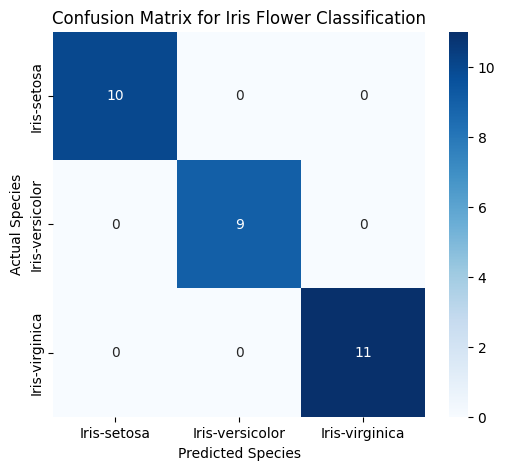

In [19]:
# Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix for Iris Flower Classification")

plt.show()

**Meaning of Code Block 9**

This code block creates a Confusion Matrix Heatmap, which provides a graphical representation of the K-Nearest Neighbour (KNN) model's classification performance. The heatmap compares the actual iris flower species with the predicted species and displays the number of correct and incorrect classifications for each of the three species. The values along the diagonal represent correctly classified flowers, while the values outside the diagonal indicate misclassified samples. A higher number of values on the diagonal signifies better model performance. This visualization enables students to quickly assess the accuracy and reliability of the KNN classification model.

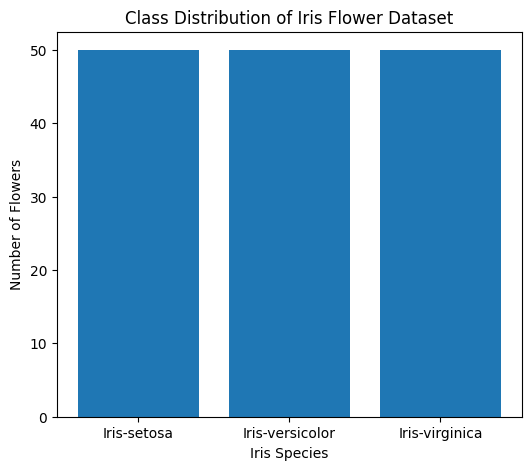

In [20]:
# Import Library
import matplotlib.pyplot as plt

# Count the Number of Samples in Each Species
class_counts = df["Species"].value_counts()

# Plot Class Distribution
plt.figure(figsize=(6,5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("Iris Species")
plt.ylabel("Number of Flowers")
plt.title("Class Distribution of Iris Flower Dataset")

plt.show()

**Meaning of Code Block 10**

This code block creates a Class Distribution Bar Chart, which displays the number of flower samples belonging to each iris species in the dataset. The graph shows the distribution of Iris-setosa, Iris-versicolor, and Iris-virginica. This visualization helps determine whether the dataset is balanced or imbalanced before training the K-Nearest Neighbour (KNN) model. A balanced dataset generally helps improve the reliability and fairness of the classification model.

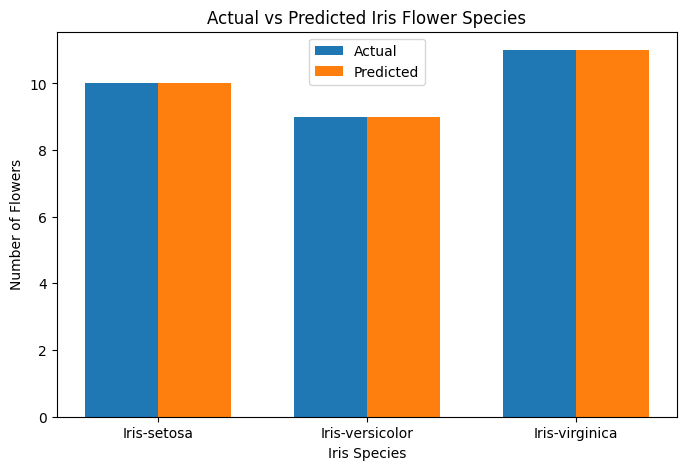

In [21]:
# Import Libraries
import matplotlib.pyplot as plt
import pandas as pd

# Count Actual and Predicted Species
actual_counts = y_test.value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()

# Plot Bar Chart
plt.figure(figsize=(8,5))

bar_width = 0.35
x = range(len(actual_counts))

plt.bar(x, actual_counts.values, width=bar_width, label="Actual")
plt.bar([i + bar_width for i in x], predicted_counts.values, width=bar_width, label="Predicted")

plt.xticks(
    [i + bar_width/2 for i in x],
    actual_counts.index
)

plt.xlabel("Iris Species")
plt.ylabel("Number of Flowers")
plt.title("Actual vs Predicted Iris Flower Species")
plt.legend()

plt.show()

**Meaning of Code Block 11**

This code block creates a Predicted vs Actual Bar Chart, which compares the number of actual and predicted iris flower species in the testing dataset. For each species (Iris-setosa, Iris-versicolor, and Iris-virginica), two bars are displayed: one representing the actual number of flowers and the other representing the number predicted by the K-Nearest Neighbour (KNN) model. If the heights of the bars are similar, it indicates that the model has accurately classified the iris flowers. This visualization provides an easy and intuitive way to assess the prediction performance of the KNN classification model.